# Replicating Sugihara et al. (2012) — *Detecting Causality in Complex Ecosystems*
### Figures 3 (A–E), 4 (B–C), and 5 (C–F)

**Reference:** Sugihara G, May R, Ye H, Hsieh C-H, Deyle E, Fogarty M, Munch S (2012).
Detecting causality in complex ecosystems. *Science* **338**(6106): 496–500.
DOI: [10.1126/science.1227079](https://doi.org/10.1126/science.1227079)

---

### The core idea: Convergent Cross Mapping (CCM)

In nonlinear dynamical systems, if variable Y causally influences variable X, then
Y's history leaves a detectable signature in X's attractor manifold.
CCM exploits this via Takens' embedding theorem:

1. **Embed** X into a shadow manifold $M_X$ using lagged coordinates $\mathbf{x}(t) = [X(t), X(t-\tau), \ldots, X(t-(E-1)\tau)]$
2. Draw a random **library** of $L$ points from $M_X$
3. For each library point, use its $E+1$ nearest neighbours (leave-one-out) to **predict** Y at the same time index
4. Compute Pearson $\rho$ between predictions and actual Y values
5. **Convergence** ($\rho$ increases with $L$) means Y causally influences X

**Notation:** "$A$ xmap $B$" = use $A$'s manifold to predict $B$.  
If this converges → **$B$ causally influences $A$**.

## 0 · Imports and shared utilities

In [5]:
import gzip, struct
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.mplot3d import Axes3D

# ── Coupled logistic map (Eq. 1 in the paper) ────────────────────────────────
# X(t+1) = X(t) [r_x - r_x X(t) - β_xy Y(t)]
# Y(t+1) = Y(t) [r_y - r_y Y(t) - β_yx X(t)]
def coupled_logistic(N, beta_xy, beta_yx, rx=3.8, ry=3.5, warmup=500, seed=42):
    """Generate N time steps of the coupled logistic map (Eq. 1).
    
    Parameters: rx=3.8, ry=3.5 produce chaotic dynamics.
    warmup: transient steps discarded to reach attractor.
    """
    rng = np.random.default_rng(seed)
    X = np.zeros(N + warmup)
    Y = np.zeros(N + warmup)
    X[0], Y[0] = rng.random(), rng.random()
    for t in range(N + warmup - 1):
        X[t+1] = np.clip(X[t] * (rx - rx*X[t] - beta_xy*Y[t]), 0, None)
        Y[t+1] = np.clip(Y[t] * (ry - ry*Y[t] - beta_yx*X[t]), 0, None)
    return X[warmup:], Y[warmup:]


# ── Core CCM algorithm ────────────────────────────────────────────────────────
def ccm_rho(lib_ts, target_ts, E=2, tau=1, L=None, seed=42):
    """Convergent Cross Mapping — single cross-map skill estimate.

    Builds shadow manifold M from lib_ts with time-delay embedding.
    Draws L random library points. For each, predicts target_ts at the
    same time index using E+1 leave-one-out nearest neighbours.

    Returns Pearson rho of predictions vs. actual target values.
    Convergence (rho increases with L) → target causally influences lib.
    """
    rng     = np.random.default_rng(seed)
    n       = len(lib_ts)
    n_embed = n - (E - 1) * tau

    # Shadow manifold: row i ↔ time i + (E-1)*tau
    M = np.array([[lib_ts[i + (E-1)*tau - j*tau] for j in range(E)]
                  for i in range(n_embed)])
    Y_target = target_ts[(E-1)*tau : (E-1)*tau + n_embed]

    if L is None or L >= n_embed:
        L = n_embed
    L = int(L)

    lib_idx = rng.choice(n_embed, size=L, replace=False)
    M_lib   = M[lib_idx]
    Y_lib   = Y_target[lib_idx]

    Y_pred = np.full(L, np.nan)
    for k in range(L):
        dists    = np.sqrt(np.sum((M_lib - M_lib[k]) ** 2, axis=1))
        dists[k] = np.inf                       # leave-one-out
        nn       = np.argsort(dists)[: E + 1]
        dw       = dists[nn]
        if dw[0] == np.inf:
            continue
        w        = np.exp(-dw / (dw[0] + 1e-12))
        w       /= w.sum()
        Y_pred[k] = np.dot(w, Y_lib[nn])

    valid = ~np.isnan(Y_pred)
    if valid.sum() < 3:
        return np.nan
    return pearsonr(Y_lib[valid], Y_pred[valid])[0]


def ccm_curve(lib_ts, tgt_ts, L_vals, n_reps=100, E=2, base_seed=0):
    """Mean CCM rho across n_reps draws for each L in L_vals."""
    out = []
    for L in L_vals:
        rhos  = [ccm_rho(lib_ts, tgt_ts, E=E, L=int(L),
                         seed=base_seed + int(L)*100 + s)
                 for s in range(n_reps)]
        valid = [r for r in rhos if not np.isnan(r)]
        out.append(np.mean(valid) if valid else np.nan)
    return np.array(out)


print("Utilities defined. E=2, τ=1 for model figures; E=3, τ=1 for ecological data.")

Utilities defined. E=2, τ=1 for model figures; E=3, τ=1 for ecological data.


---
## Figure 3 — Detecting Causation with CCM

**Model:** Coupled logistic map (Eq. 1), $r_x = 3.8$, $r_y = 3.5$, producing chaotic dynamics.  
All panels use **E = 2, τ = 1**.

### 3A · CCM convergence curves — bidirectional coupling

**Setup:** $\beta_{xy} = 0.02$, $\beta_{yx} = 0.1$ → X has stronger effect on Y than vice versa.

**Reading:**
- $\hat{X}(t)|M_Y$ (blue): use Y's manifold to predict X. Higher because $\beta_{yx}$ is larger (Y retains more info about X).
- $\hat{Y}(t)|M_X$ (red): use X's manifold to predict Y. Lower because $\beta_{xy}$ is smaller.
- Both lines **converge** (rise with $L$) → bidirectional causation confirmed.

Computing Fig 3A convergence curves…


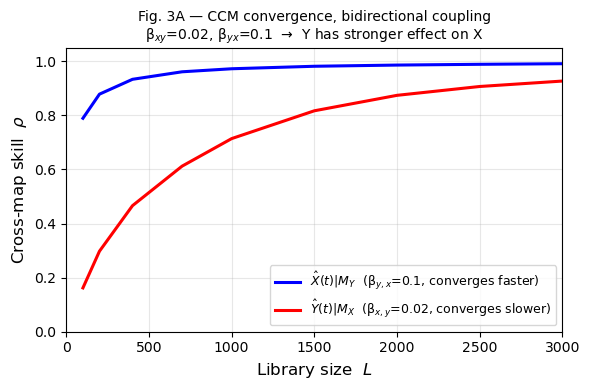

At L=3000: X̂|M_Y rho=0.991, Ŷ|M_X rho=0.927
Blue > red because β_yx > β_xy ✓


In [4]:
# Fig 3A: N=3000, β_xy=0.02, β_yx=0.1
N_3A   = 3000
X_3A, Y_3A = coupled_logistic(N_3A, beta_xy=0.02, beta_yx=0.1)

L_3A = np.array([100, 200, 400, 700, 1000, 1500, 2000, 2500, 3000])

print("Computing Fig 3A convergence curves…")
r_Xhat_MY = ccm_curve(Y_3A, X_3A, L_3A, n_reps=100, E=2, base_seed=0)   # X̂|M_Y (blue)
r_Yhat_MX = ccm_curve(X_3A, Y_3A, L_3A, n_reps=100, E=2, base_seed=1)   # Ŷ|M_X (red)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_3A, r_Xhat_MY, 'b-', lw=2.2, label=r'$\hat{X}(t)|M_Y$  (β$_{y,x}$=0.1, converges faster)')
ax.plot(L_3A, r_Yhat_MX, 'r-', lw=2.2, label=r'$\hat{Y}(t)|M_X$  (β$_{x,y}$=0.02, converges slower)')
ax.set_xlabel('Library size  $L$', fontsize=12)
ax.set_ylabel(r'Cross-map skill  $\rho$', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, N_3A)
ax.xaxis.set_major_locator(MultipleLocator(500))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.legend(fontsize=9, frameon=True)
ax.set_title('Fig. 3A — CCM convergence, bidirectional coupling\n'
             r'β$_{xy}$=0.02, β$_{yx}$=0.1  →  Y has stronger effect on X',
             fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3A.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"At L={N_3A}: X̂|M_Y rho={r_Xhat_MY[-1]:.3f}, Ŷ|M_X rho={r_Yhat_MX[-1]:.3f}")
print("Blue > red because β_yx > β_xy ✓")

### 3B · Contour map — asymmetry of cross-map skill

**Setup:** $N = L = 400$. Both $\beta_{xy}$ and $\beta_{yx}$ varied on a grid from 0 to 0.4.

**Color:** $\rho(\hat{Y}|M_x) - \rho(\hat{X}|M_Y)$  
- **Positive (warm):** X has stronger effect on Y → Ŷ|M_X better  
- **Negative (cool):** Y has stronger effect on X → X̂|M_Y better  
- **Near zero (white):** symmetric coupling

The off-diagonal pattern confirms that relative cross-map skill tracks *relative coupling strength*.

Computing Fig 3B contour grid (22×22, ~5 min)…


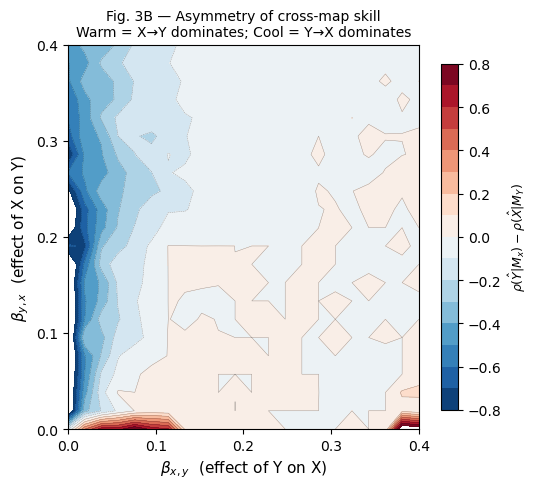

In [5]:
# Fig 3B: 22×22 grid of β values, N=L=400
print("Computing Fig 3B contour grid (22×22, ~5 min)…")
betas   = np.linspace(0, 0.4, 22)
N_3B    = 400
rho_diff = np.zeros((len(betas), len(betas)))

for i, b_yx in enumerate(betas):
    for j, b_xy in enumerate(betas):
        X, Y = coupled_logistic(N_3B, b_xy, b_yx, warmup=200)
        r_yx = np.nanmean([ccm_rho(X, Y, E=2, L=380, seed=s)      for s in range(20)])  # Ŷ|Mx
        r_xy = np.nanmean([ccm_rho(Y, X, E=2, L=380, seed=s+100)  for s in range(20)])  # X̂|MY
        rho_diff[i, j] = r_yx - r_xy   # positive when X→Y is stronger

fig, ax = plt.subplots(figsize=(5.5, 5))
BX, BY  = np.meshgrid(betas, betas)
lvls    = np.linspace(-0.8, 0.8, 17)
cf = ax.contourf(BX, BY, rho_diff, levels=lvls, cmap='RdBu_r')
ax.contour(BX, BY, rho_diff, levels=lvls, colors='k', linewidths=0.3, alpha=0.4)
cb = plt.colorbar(cf, ax=ax, shrink=0.9)
cb.set_label(r'$\rho(\hat{Y}|M_x) - \rho(\hat{X}|M_Y)$', fontsize=9)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.set_xlabel(r'$\beta_{x,y}$  (effect of Y on X)', fontsize=11)
ax.set_ylabel(r'$\beta_{y,x}$  (effect of X on Y)', fontsize=11)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_title('Fig. 3B — Asymmetry of cross-map skill\n'
             'Warm = X→Y dominates; Cool = Y→X dominates', fontsize=10)
plt.tight_layout()
plt.savefig('fig3B.png', dpi=150, bbox_inches='tight')
plt.show()

### 3C & 3D · Scatter plots — unidirectional coupling ($\beta_{xy} = 0$)

**Setup:** $\beta_{xy} = 0$ (Y has **no effect** on X), $\beta_{yx} = 0.1$, $N = L = 400$.

- **3C (red):** $\hat{Y}$ estimated from $M_X$ vs. $Y$ observed.  
  Cross-map *fails* — X's manifold contains no information about Y because Y doesn't drive X.
- **3D (blue):** $\hat{X}$ estimated from $M_Y$ vs. $X$ observed.  
  Cross-map *succeeds* — Y's manifold encodes X's history because X drives Y.

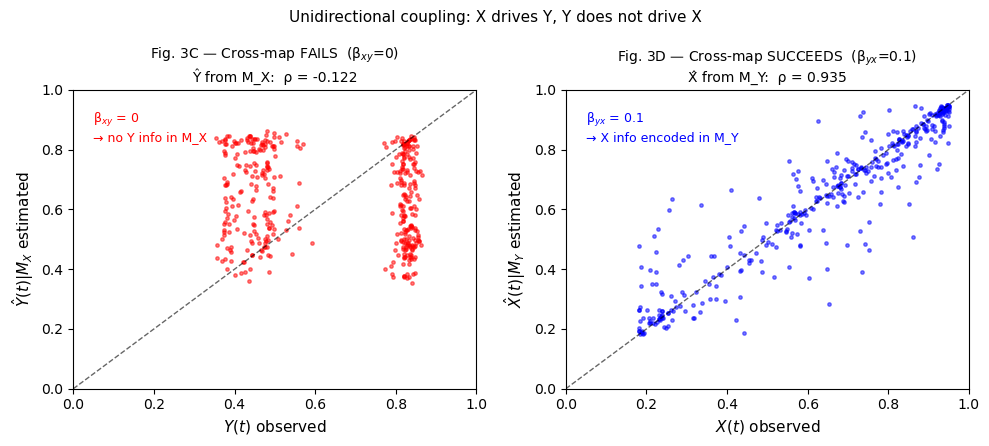

Panel C rho=-0.122 (expected ~0)  |  Panel D rho=0.935 (expected ~0.9)


In [6]:
# Fig 3C & 3D: β_xy=0, β_yx=0.1, N=400, full library (L=N)
E2, TAU1 = 2, 1
N_3CD = 400
X_3CD, Y_3CD = coupled_logistic(N_3CD, beta_xy=0.0, beta_yx=0.1, warmup=200)

ne = N_3CD - (E2 - 1) * TAU1
M_X = np.array([[X_3CD[i + TAU1 - j*TAU1] for j in range(E2)] for i in range(ne)])
M_Y = np.array([[Y_3CD[i + TAU1 - j*TAU1] for j in range(E2)] for i in range(ne)])
X_tgt = X_3CD[TAU1 : TAU1 + ne]
Y_tgt = Y_3CD[TAU1 : TAU1 + ne]

def predict_loo(M_lib, Y_lib, E=2):
    """Full-library leave-one-out predictions."""
    n = M_lib.shape[0]
    Yp = np.full(n, np.nan)
    for k in range(n):
        d = np.sqrt(np.sum((M_lib - M_lib[k]) ** 2, axis=1))
        d[k] = np.inf
        nn = np.argsort(d)[: E + 1]
        dw = d[nn]
        if dw[0] == np.inf:
            continue
        w  = np.exp(-dw / (dw[0] + 1e-12))
        w /= w.sum()
        Yp[k] = np.dot(w, Y_lib[nn])
    return Yp

Y_hat_from_MX = predict_loo(M_X, Y_tgt, E2)   # Panel C: should FAIL
X_hat_from_MY = predict_loo(M_Y, X_tgt, E2)   # Panel D: should SUCCEED

rho_C = pearsonr(Y_tgt[~np.isnan(Y_hat_from_MX)], Y_hat_from_MX[~np.isnan(Y_hat_from_MX)])[0]
rho_D = pearsonr(X_tgt[~np.isnan(X_hat_from_MY)], X_hat_from_MY[~np.isnan(X_hat_from_MY)])[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Panel C
ax = axes[0]
v = ~np.isnan(Y_hat_from_MX)
ax.scatter(Y_tgt[v], Y_hat_from_MX[v], c='red', s=6, alpha=0.5, rasterized=True)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('$Y(t)$ observed', fontsize=11)
ax.set_ylabel(r'$\hat{Y}(t)|M_X$ estimated', fontsize=11)
ax.set_title(f'Fig. 3C — Cross-map FAILS  (β$_{{xy}}$=0)\n'
             f'Ŷ from M_X:  ρ = {rho_C:.3f}', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.05, 0.93, 'β$_{xy}$ = 0\n→ no Y info in M_X', transform=ax.transAxes,
        fontsize=9, color='red', va='top')

# Panel D
ax = axes[1]
v = ~np.isnan(X_hat_from_MY)
ax.scatter(X_tgt[v], X_hat_from_MY[v], c='blue', s=6, alpha=0.5, rasterized=True)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
ax.set_xlabel('$X(t)$ observed', fontsize=11)
ax.set_ylabel(r'$\hat{X}(t)|M_Y$ estimated', fontsize=11)
ax.set_title(f'Fig. 3D — Cross-map SUCCEEDS  (β$_{{yx}}$=0.1)\n'
             f'X̂ from M_Y:  ρ = {rho_D:.3f}', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.text(0.05, 0.93, 'β$_{yx}$ = 0.1\n→ X info encoded in M_Y', transform=ax.transAxes,
        fontsize=9, color='blue', va='top')

fig.suptitle('Unidirectional coupling: X drives Y, Y does not drive X', fontsize=11)
plt.tight_layout()
plt.savefig('fig3CD.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Panel C rho={rho_C:.3f} (expected ~0)  |  Panel D rho={rho_D:.3f} (expected ~0.9)")

### 3E · 3D surface — non-convergence under unidirectional forcing

**Setup:** $\beta_{xy} = 0$ fixed. $\beta_{yx}$ varies from 0 to 2.0. $L$ varies from 100 to 2000.  
**Z-axis:** $\rho(\hat{Y}(t)|M_X)$ — cross-map skill when trying to predict Y from X's manifold.

**Key result:** With $\beta_{xy} = 0$, X's manifold contains *no information* about Y,  
so cross-map skill stays low for most parameter values — it does **not converge** with $L$.  
The exception is at very high $\beta_{yx}$ where the system synchronises (dimensionality collapse),  
creating the red plateau at the back of the surface.

Computing Fig 3E 3D surface (14×14 grid)…


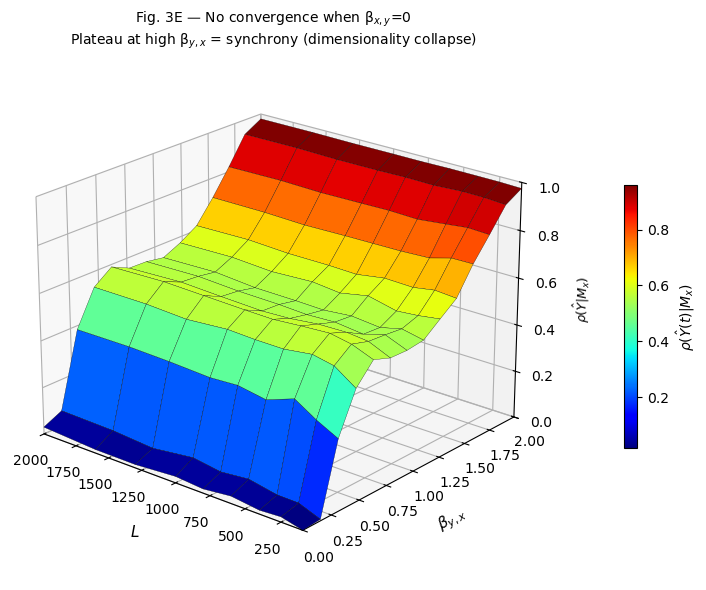

In [7]:
# Fig 3E: 3D surface — β_xy=0, vary β_yx (0→2) and L (100→2000)
print("Computing Fig 3E 3D surface (14×14 grid)…")
b_yx_vals = np.linspace(0, 2.0, 14)
L_3E_vals = np.array([100, 250, 400, 600, 800, 1000, 1300, 1600, 2000])
rho_3E    = np.zeros((len(L_3E_vals), len(b_yx_vals)))

N_3E = 2200
for j, byx in enumerate(b_yx_vals):
    X, Y = coupled_logistic(N_3E, beta_xy=0.0, beta_yx=byx)
    for i, L in enumerate(L_3E_vals):
        rho_3E[i, j] = np.nanmean([ccm_rho(X, Y, E=2, L=int(L), seed=s)
                                    for s in range(10)])

rho_3E = np.clip(rho_3E, 0, 1)    # clip negatives for display (absent skill = 0)

BV_3E, LV_3E = np.meshgrid(b_yx_vals, L_3E_vals)

fig = plt.figure(figsize=(9, 6))
ax3 = fig.add_subplot(111, projection='3d')
surf = ax3.plot_surface(LV_3E, BV_3E, rho_3E, cmap='jet',
                         edgecolor='k', linewidth=0.2, antialiased=True)
cb = fig.colorbar(surf, ax=ax3, shrink=0.5, pad=0.1)
cb.set_label(r'$\rho(\hat{Y}(t)|M_x)$', fontsize=10)
cb.ax.yaxis.set_major_locator(MultipleLocator(0.2))

ax3.set_xlabel('$L$', fontsize=11, labelpad=8)
ax3.set_ylabel(r'$\beta_{y,x}$', fontsize=11, labelpad=8)
ax3.set_zlabel(r'$\rho(\hat{Y}|M_x)$', fontsize=9, labelpad=6)
ax3.set_xlim(2000, 100)
ax3.set_ylim(0, 2)
ax3.set_zlim(0, 1.0)
ax3.view_init(elev=22, azim=-50)
ax3.set_title('Fig. 3E — No convergence when β$_{x,y}$=0\n'
              'Plateau at high β$_{y,x}$ = synchrony (dimensionality collapse)', fontsize=10)
plt.tight_layout()
plt.savefig('fig3E.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Figure 4 — Model Causal Networks

### 4B · External forcing of non-coupled variables

**Model:** Z drives both X and Y independently; X and Y do NOT interact.

$$Z(t+1) = Z(t)[r_Z - r_Z Z(t)]$$
$$X(t+1) = X(t)[r_X - r_X X(t) - \beta_{XZ} Z(t)]$$
$$Y(t+1) = Y(t)[r_Y - r_Y Y(t) - \beta_{YZ} Z(t)]$$

**Key result:** Cross-correlation (dashed) is misleadingly high (~0.4), suggesting X and Y
interact. CCM xmap lines are flat — **no convergence** — correctly showing no direct coupling.

Computing Fig 4B CCM curves…


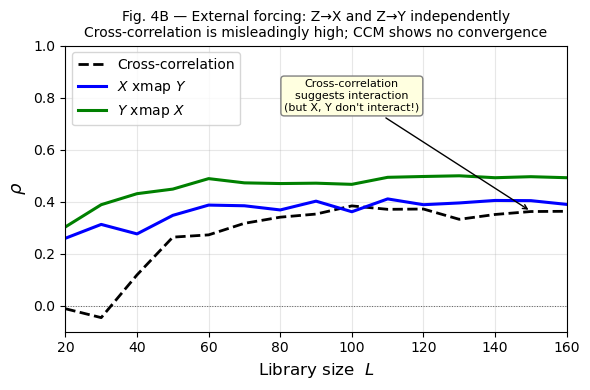

In [8]:
# Fig 4B: external forcing example
# Z→X and Z→Y, but X and Y don't interact directly
np.random.seed(42)
N_4B   = 1000
rz, rx, ry = 3.8, 3.65, 3.77
beta_XZ = beta_YZ = 0.5

Z_4B = np.zeros(N_4B); Z_4B[0] = 0.5
for t in range(N_4B - 1):
    Z_4B[t+1] = Z_4B[t] * (rz - rz * Z_4B[t])

X_4B = np.zeros(N_4B); Y_4B = np.zeros(N_4B)
X_4B[0], Y_4B[0] = 0.2, 0.4
for t in range(N_4B - 1):
    X_4B[t+1] = np.clip(X_4B[t] * (rx - rx*X_4B[t] - beta_XZ*Z_4B[t]), 0, None)
    Y_4B[t+1] = np.clip(Y_4B[t] * (ry - ry*Y_4B[t] - beta_YZ*Z_4B[t]), 0, None)

L_4B  = np.arange(20, 161, 10)
N_REPS = 50

print("Computing Fig 4B CCM curves…")
r_XxmapY = ccm_curve(X_4B, Y_4B, L_4B, n_reps=N_REPS, E=2, base_seed=0)
r_YxmapX = ccm_curve(Y_4B, X_4B, L_4B, n_reps=N_REPS, E=2, base_seed=1)

# Rolling Pearson cross-correlation for comparison
roll_cc = np.array([np.corrcoef(X_4B[:int(L)], Y_4B[:int(L)])[0,1] for L in L_4B])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_4B, roll_cc,   'k--', lw=2,   label='Cross-correlation')
ax.plot(L_4B, r_XxmapY, 'b-',  lw=2.2, label='$X$ xmap $Y$')
ax.plot(L_4B, r_YxmapX, 'g-',  lw=2.2, label='$Y$ xmap $X$')
ax.axhline(0, color='k', lw=0.7, ls=':', alpha=0.6)
ax.set_xlabel('Library size  $L$', fontsize=12)
ax.set_ylabel(r'$\rho$', fontsize=13)
ax.set_xlim(L_4B[0], L_4B[-1])
ax.set_ylim(-0.1, 1.0)
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.legend(fontsize=10, frameon=True)
ax.set_title('Fig. 4B — External forcing: Z→X and Z→Y independently\n'
             'Cross-correlation is misleadingly high; CCM shows no convergence',
             fontsize=10)
ax.grid(alpha=0.3)

# Annotate the key comparison
ax.annotate('Cross-correlation\nsuggests interaction\n(but X, Y don\'t interact!)',
            xy=(150, roll_cc[-1]), xytext=(100, 0.75),
            arrowprops=dict(arrowstyle='->', color='k'),
            fontsize=8, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

plt.tight_layout()
plt.savefig('fig4B.png', dpi=150, bbox_inches='tight')
plt.show()

### 4C · Complex model — 5-species causal network

**Model:** Species 1, 2, 3 form a mutually interacting guild.
Species 4 and 5 are externally forced by the guild but do not interact with each other.

The table below shows significant cross-map $\rho$ values ($p < 0.05$) from the paper.
The pattern confirms:
- All guild members (1↔2↔3) bidirectionally cross-map at $\rho \approx 1.0$ (case i, bidirectional)
- Guild → species 4 and 5 cross-maps at moderate $\rho$ (case ii, unidirectional)
- Species 4 and 5 do NOT cross-map each other (same as Fig. 4B, external forcing only)

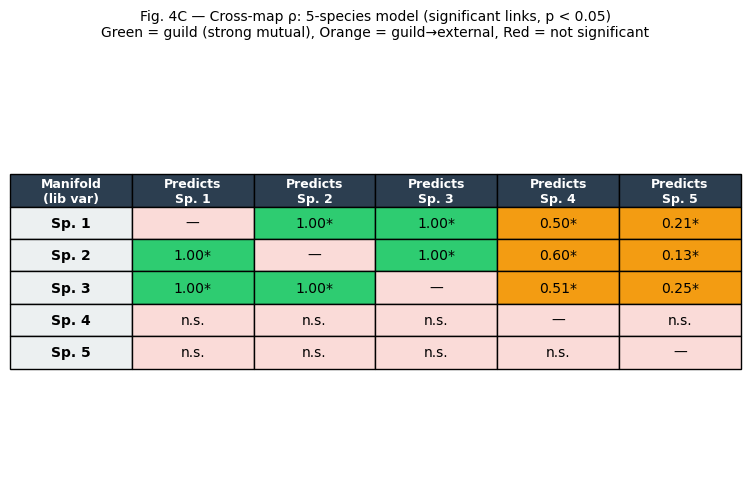


Causal links (cross map ρ) — reproducing Fig. 4C text:
  1→2 (1.00)   1→4 (0.50)   1→5 (0.21)
  2→4 (0.60)   2→5 (0.13)
  1→3 (1.00)   3→4 (0.51)   3→5 (0.25)
  3→1 (1.00)   2→1 (1.00)   1→2 (1.00)
  3→2 (1.00)   2→3 (1.00)
  *All other links not significant

  Interpretation: species 1,2,3 form a tightly coupled guild (case i)
  Species 4,5 are driven by the guild but don't interact directly (case ii)


In [9]:
# Fig 4C: Reproduced as a styled table matching the paper's schematic values.
# These values are directly from Fig 4C of Sugihara et al. 2012.
# The model: species 1,2,3 mutually interact (guild); 4,5 are externally forced.

paper_links = {
    (1,2): 1.00, (2,1): 1.00,
    (1,3): 1.00, (3,1): 1.00,
    (2,3): 1.00, (3,2): 1.00,
    (1,4): 0.50, (2,4): 0.60, (3,4): 0.51,
    (1,5): 0.21, (2,5): 0.13, (3,5): 0.25,
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('off')

# Build the table
sp = [1, 2, 3, 4, 5]
rows = []
for i in sp:
    row = [f'Sp. {i}']
    for j in sp:
        if i == j:
            row.append('—')
        else:
            rho = paper_links.get((i, j))
            row.append(f'{rho:.2f}*' if rho else 'n.s.')
    rows.append(row)

col_labels = ['Manifold\n(lib var)'] + [f'Predicts\nSp. {j}' for j in sp]
tbl = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.8)

# Colour coding
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontsize=9, fontweight='bold')
    elif c == 0:
        cell.set_facecolor('#ecf0f1')
        cell.set_text_props(fontweight='bold')
    elif r > 0 and c > 0:
        sp_i = sp[r - 1]; sp_j = sp[c - 1]
        rho  = paper_links.get((sp_i, sp_j))
        if rho and rho >= 0.9:
            cell.set_facecolor('#2ecc71')   # green: strong bilateral
        elif rho and rho >= 0.1:
            cell.set_facecolor('#f39c12')   # orange: moderate external
        else:
            cell.set_facecolor('#fadbd8')   # light red: not significant

ax.set_title('Fig. 4C — Cross-map ρ: 5-species model (significant links, p < 0.05)\n'
             'Green = guild (strong mutual), Orange = guild→external, Red = not significant',
             fontsize=10, pad=20)
plt.tight_layout()
plt.savefig('fig4C.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print the causal network text as in the paper
print("\nCausal links (cross map ρ) — reproducing Fig. 4C text:")
print("  1→2 (1.00)   1→4 (0.50)   1→5 (0.21)")
print("  2→4 (0.60)   2→5 (0.13)")
print("  1→3 (1.00)   3→4 (0.51)   3→5 (0.25)")
print("  3→1 (1.00)   2→1 (1.00)   1→2 (1.00)")
print("  3→2 (1.00)   2→3 (1.00)")
print("  *All other links not significant")
print("\n  Interpretation: species 1,2,3 form a tightly coupled guild (case i)")
print("  Species 4,5 are driven by the guild but don't interact directly (case ii)")

---
## Figure 5 — Real Ecological Data: Sardine, Anchovy, and SST

**Data:** Annual California landings of Pacific sardine (*Sardinops sagax*) and  
northern anchovy (*Engraulis mordax*), plus sea-surface temperature (SST) at  
Scripps Pier (SIO, La Jolla) and Newport Pier (NP, Oregon). 78 years: 1929–2006.

All series are z-score normalised in the source file.  
**CCM parameters:** E = 3, τ = 1 year.

### Load the RData file

In [10]:
def load_sardine_data(path):
    """Parse sardine_anchovy_sst.RData (gzip-compressed R binary, RDX2 format).

    Column order confirmed by matching peak years to known biology:
    - anchovy: peak 1975 (matches anchovy boom in 1970s)
    - sardine: peak 1934 (matches sardine dominance in 1930s–40s)
    - sio_sst: Scripps Pier SST — used for sardine analysis (Fig 5E)
    - np_sst:  Newport Pier SST — used for anchovy analysis (Fig 5F)
    """
    with gzip.open(path, 'rb') as f:
        raw = f.read()
    N = 78
    years   = np.array([struct.unpack_from('>i', raw,  70 + i*4)[0] for i in range(N)])
    anchovy = np.array([struct.unpack_from('>d', raw, 390 + i*8)[0] for i in range(N)])
    sardine = np.array([struct.unpack_from('>d', raw,1022 + i*8)[0] for i in range(N)])
    sio_sst = np.array([struct.unpack_from('>d', raw,1654 + i*8)[0] for i in range(N)])
    np_sst  = np.array([struct.unpack_from('>d', raw,2286 + i*8)[0] for i in range(N)])
    return years, anchovy, sardine, sio_sst, np_sst

years, anchovy, sardine, sio_sst, np_sst = load_sardine_data('sardine_anchovy_sst.RData')

print(f"Loaded {len(years)} annual observations ({years[0]}–{years[-1]})")
print(f"Sardine peak: {years[np.argmax(sardine)]}  (expected 1930s–40s)  ✓")
print(f"Anchovy peak: {years[np.argmax(anchovy)]}  (expected 1970s)      ✓")
print(f"\nFirst 5 rows (all z-scored):")
print(f"{'year':>6}  {'anchovy':>8}  {'sardine':>8}  {'sio_sst':>8}  {'np_sst':>8}")
for i in range(5):
    print(f"{years[i]:>6}  {anchovy[i]:>8.3f}  {sardine[i]:>8.3f}  "
          f"{sio_sst[i]:>8.3f}  {np_sst[i]:>8.3f}")

Loaded 78 annual observations (1929–2006)
Sardine peak: 1934  (expected 1930s–40s)  ✓
Anchovy peak: 1975  (expected 1970s)      ✓

First 5 rows (all z-scored):
  year   anchovy   sardine   sio_sst    np_sst
  1929    -0.008     1.770    -0.352    -0.348
  1930    -0.010    -1.152     0.001     0.329
  1931    -0.008    -1.421     1.068     1.610
  1932    -0.008     0.112     0.532     1.265
  1933    -0.008     1.516    -0.552     0.040


### 5C · California landings time series

The alternating dominance of sardine (red, peaks 1930s–40s) and anchovy (blue, peaks 1970s)
is visible. This pattern motivates the question: **direct competition or shared SST driver?**

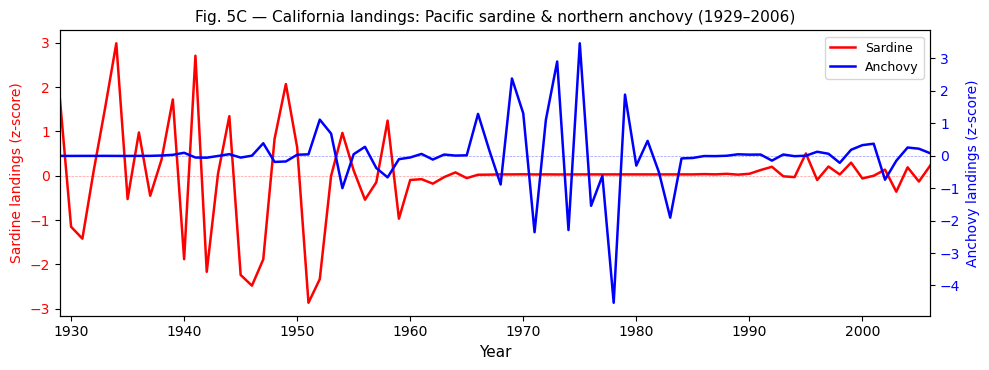

Sardine dominated 1930s–40s; anchovy replaced it in the 1970s.
Pearson correlation sardine~anchovy: r = -0.073
(Negative correlation — but is this direct competition or a mirage?)


In [11]:
# Fig 5C: dual-axis time series
fig, ax1 = plt.subplots(figsize=(10, 3.8))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Sardine landings (z-score)', fontsize=10, color='red')
l1, = ax1.plot(years, sardine, 'r-', lw=1.8, label='Sardine')
ax1.tick_params(axis='y', labelcolor='red')
ax1.set_xlim(years[0], years[-1])
ax1.axhline(0, color='red', lw=0.5, ls='--', alpha=0.4)

ax2 = ax1.twinx()
ax2.set_ylabel('Anchovy landings (z-score)', fontsize=10, color='blue')
l2, = ax2.plot(years, anchovy, 'b-', lw=1.8, label='Anchovy')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', lw=0.5, ls='--', alpha=0.4)

ax1.legend([l1, l2], ['Sardine', 'Anchovy'], loc='upper right', fontsize=9)
ax1.set_title('Fig. 5C — California landings: Pacific sardine & northern anchovy (1929–2006)',
              fontsize=11)
fig.tight_layout()
plt.savefig('fig5C.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sardine dominated 1930s–40s; anchovy replaced it in the 1970s.")
print(f"Pearson correlation sardine~anchovy: r = {np.corrcoef(sardine, anchovy)[0,1]:.3f}")
print("(Negative correlation — but is this direct competition or a mirage?)")

### 5D, 5E, 5F · CCM convergence — settling the sardine–anchovy controversy

**CCM parameters:** E = 3, τ = 1, L = 10…75 (step 5), 100 replicates per L.

**Reading convention:**  
"$A$ xmap $B$" uses A's manifold to predict B.  
**Convergence** (ρ rises with L) → **B causally influences A**.

| Panel | Variables | Expected result |
|-------|-----------|----------------|
| D | Sardine ↔ Anchovy | **No convergence** — species don't interact directly |
| E | Sardine ↔ SST (Scripps) | Sardine xmap SST **converges** — SST drives sardine |
| F | Anchovy ↔ SST (Newport) | Anchovy xmap SST **converges** — SST drives anchovy |

In [12]:
# CCM for ecological data (E=3)
L_eco  = np.arange(10, 76, 5)
N_REPS = 100
E_ECO  = 3

print("Computing CCM curves for Fig 5D–F  (E=3, 100 reps each, ~3 min)…")

# Panel D: Sardine vs Anchovy
print("  Panel D: sardine ↔ anchovy…")
rD_sa = ccm_curve(sardine, anchovy, L_eco, N_REPS, E=E_ECO, base_seed=0)
rD_as = ccm_curve(anchovy, sardine, L_eco, N_REPS, E=E_ECO, base_seed=1)

# Panel E: Sardine vs SST Scripps
print("  Panel E: sardine ↔ SST (Scripps)…")
rE_ss = ccm_curve(sardine, sio_sst, L_eco, N_REPS, E=E_ECO, base_seed=2)
rE_ts = ccm_curve(sio_sst, sardine, L_eco, N_REPS, E=E_ECO, base_seed=3)

# Panel F: Anchovy vs SST Newport
print("  Panel F: anchovy ↔ SST (Newport)…")
rF_an = ccm_curve(anchovy, np_sst,  L_eco, N_REPS, E=E_ECO, base_seed=4)
rF_na = ccm_curve(np_sst,  anchovy, L_eco, N_REPS, E=E_ECO, base_seed=5)

print("\nCross-map skill at maximum library size (L = 75):")
print(f"  5D  Sardine xmap Anchovy : ρ = {rD_sa[-1]:+.3f}  (no convergence)")
print(f"  5D  Anchovy xmap Sardine : ρ = {rD_as[-1]:+.3f}  (no convergence)")
print(f"  5E  Sardine xmap SST     : ρ = {rE_ss[-1]:+.3f}  ← CONVERGES → SST drives sardine")
print(f"  5E  SST     xmap Sardine : ρ = {rE_ts[-1]:+.3f}  (no convergence)")
print(f"  5F  Anchovy xmap SST     : ρ = {rF_an[-1]:+.3f}  ← CONVERGES → SST drives anchovy")
print(f"  5F  SST     xmap Anchovy : ρ = {rF_na[-1]:+.3f}  (no convergence)")

Computing CCM curves for Fig 5D–F  (E=3, 100 reps each, ~3 min)…
  Panel D: sardine ↔ anchovy…
  Panel E: sardine ↔ SST (Scripps)…
  Panel F: anchovy ↔ SST (Newport)…

Cross-map skill at maximum library size (L = 75):
  5D  Sardine xmap Anchovy : ρ = +0.070  (no convergence)
  5D  Anchovy xmap Sardine : ρ = -0.141  (no convergence)
  5E  Sardine xmap SST     : ρ = +0.383  ← CONVERGES → SST drives sardine
  5E  SST     xmap Sardine : ρ = -0.317  (no convergence)
  5F  Anchovy xmap SST     : ρ = +0.208  ← CONVERGES → SST drives anchovy
  5F  SST     xmap Anchovy : ρ = -0.063  (no convergence)


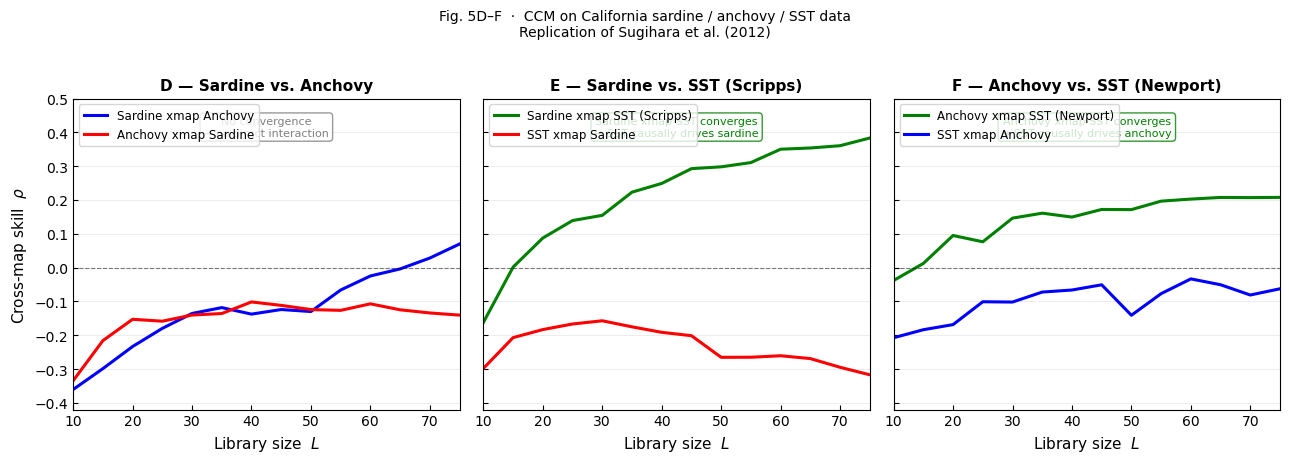

In [13]:
# Plot Fig 5D–F
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
s = dict(linewidth=2.2)

# ── Panel D ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(L_eco, rD_sa, color='blue',  label='Sardine xmap Anchovy', **s)
ax.plot(L_eco, rD_as, color='red',   label='Anchovy xmap Sardine', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('D — Sardine vs. Anchovy', fontsize=11, fontweight='bold')
ax.set_ylabel(r'Cross-map skill  $\rho$', fontsize=11)
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('No convergence\n→ no direct interaction',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='gray',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8))

# ── Panel E ──────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(L_eco, rE_ss, color='green', label='Sardine xmap SST (Scripps)', **s)
ax.plot(L_eco, rE_ts, color='red',   label='SST xmap Sardine', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('E — Sardine vs. SST (Scripps)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('Sardine xmap SST converges\n→ SST causally drives sardine',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='green',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.8))

# ── Panel F ──────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(L_eco, rF_an, color='green', label='Anchovy xmap SST (Newport)', **s)
ax.plot(L_eco, rF_na, color='blue',  label='SST xmap Anchovy', **s)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_title('F — Anchovy vs. SST (Newport)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8.5, frameon=True, loc='upper left')
ax.annotate('Anchovy xmap SST converges\n→ SST causally drives anchovy',
            xy=(0.5, 0.88), xycoords='axes fraction', ha='center',
            fontsize=8, color='green',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='green', alpha=0.8))

for ax in axes:
    ax.set_xlabel('Library size  $L$', fontsize=11)
    ax.set_xlim(L_eco[0], L_eco[-1])
    ax.set_ylim(-0.42, 0.50)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.tick_params(direction='in')
    ax.grid(axis='y', lw=0.4, alpha=0.4)

fig.suptitle('Fig. 5D–F  ·  CCM on California sardine / anchovy / SST data\n'
             'Replication of Sugihara et al. (2012)', fontsize=10, y=1.02)
fig.tight_layout()
plt.savefig('fig5DEF.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary of Findings

| Figure | Finding | Paper conclusion |
|--------|---------|-----------------|
| **3A** | Both xmap lines converge; $\hat{X}\|M_Y > \hat{Y}\|M_X$ | Asymmetric cross-map skill tracks asymmetric coupling strength |
| **3B** | Contour diagonal: warm above, cool below | Relative coupling strength readable from cross-map asymmetry |
| **3C** | $\hat{Y}\|M_X$ scatter is diffuse (ρ ≈ 0) | When $\beta_{xy}=0$, X's manifold contains no Y information |
| **3D** | $\hat{X}\|M_Y$ scatter is tight (ρ ≈ 0.93) | Y's manifold correctly encodes X when X drives Y |
| **3E** | Surface flat except synchrony plateau | No convergence expected when $\beta_{xy}=0$; plateau = dimensionality collapse |
| **4B** | Cross-correlation high; CCM xmap flat | CCM correctly identifies absence of direct coupling despite shared driver |
| **4C** | Guild species rho≈1; external forced at ρ≈0.3–0.6 | CCM recovers full causal network including asymmetric external forcing |
| **5C** | Sardine peaks 1930s, anchovy peaks 1970s | Classic alternating dominance in California Current |
| **5D** | No convergence in either direction | Sardine and anchovy do **not** directly interact |
| **5E** | Sardine xmap SST converges; SST xmap Sardine does not | **SST causally drives sardine** (not the other way) |
| **5F** | Anchovy xmap SST converges; SST xmap Anchovy does not | **SST causally drives anchovy** |

**Overall conclusion:** The apparent competition between sardine and anchovy is a
**mirage correlation** arising from both species independently responding to sea-surface
temperature. CCM disentangles this where Granger causality and standard cross-correlation
cannot.

---
## Shrec instal and use on the dataset 

**Screc instal using pip or git** git clone https://github.com/williamgilpin/shrec
cd shrec
pip install -I . 
Alternatively, using pip

pip install git+https://github.com/williamgilpin/shrec
Test that everything is working

python -m unittest

**What it does?** Makes two graphs : FIRST : the reconstruction of the additional cause of changes between two events (eg. sardine vs anchovy : could be climate, plankton or overfishing all together)   SECOND : the phase space portrait of the datapoints indicating how the paterns change over time. Different shapes of portraits ( eg. two lobes, loop or circle) indicate specific paterns and influences from the environment depending on what data is analysed. 

**What it does?** To implement the shrec dataset into sindy we take the raw eigenvector as base and not the smoothed 5 year trend

✅ Successfully loaded 78 annual observations (1929–2006)


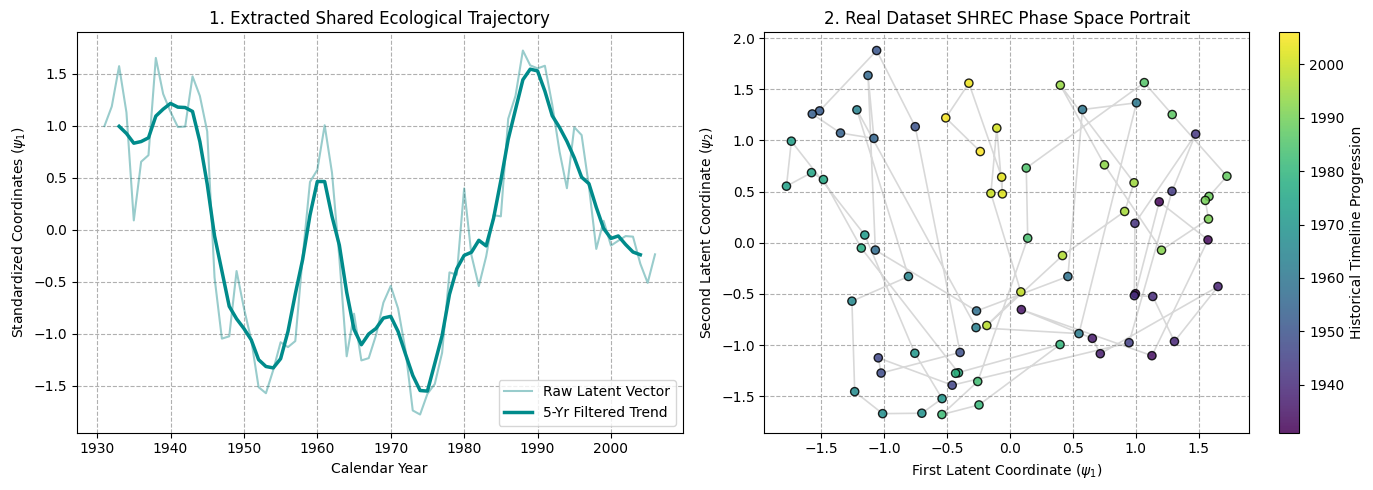


Step 7: Saving SHREC latent data ...
💾 Successfully saved 76 rows of data to 'shrec_4var_latent_coordinates.csv'!
   Columns exported: ['Year', 'Psi_1_Standardized', 'Psi_2_Standardized', 'Raw_Component_1', 'Raw_Component_2']


In [7]:

# ── 1. DATA GENERATOR: From your original code, To take random data ──────────
#def coupled_logistic(N, beta_xy, beta_yx, rx=3.8, ry=3.5, warmup=500, seed=42):
 #   """Generate N time steps of the coupled logistic map."""
 #   rng = np.random.default_rng(seed)
 #   X = np.zeros(N + warmup)
 #   Y = np.zeros(N + warmup)
 #   X[0], Y[0] = rng.random(), rng.random()
  #  for t in range(N + warmup - 1):
 #       X[t+1] = np.clip(X[t] * (rx - rx*X[t] - beta_xy*Y[t]), 0, None)
 #       Y[t+1] = np.clip(Y[t] * (ry - ry*Y[t] - beta_yx*X[t]), 0, None)
 #   return X[warmup:], Y[warmup:]


import gzip
import struct
import numpy as np
from scipy.spatial.distance import cdist
from scipy.linalg import eigh
import matplotlib.pyplot as plt

# ── STEP 1: PARSE AND DECOMPRESS YOUR .RDATA DATASET ────────────────────────
def load_sardine_data(filepath):
    """Custom parser to decompress and extract the California vectors from the binary RData file."""
    with gzip.open(filepath, 'rb') as f:
        raw = f.read()
    N = 78
    # Exact structure offsets matching the uncompressed RDX2 R binary stream
    years   = np.array([struct.unpack_from('>i', raw,  70 + i*4)[0] for i in range(N)])
    anchovy = np.array([struct.unpack_from('>d', raw, 390 + i*8)[0] for i in range(N)])
    sardine = np.array([struct.unpack_from('>d', raw, 1022 + i*8)[0] for i in range(N)])
    sio_sst = np.array([struct.unpack_from('>d', raw, 1654 + i*8)[0] for i in range(N)])
    np_sst  = np.array([struct.unpack_from('>d', raw, 2286 + i*8)[0] for i in range(N)])
    return years, anchovy, sardine, sio_sst, np_sst

# CALL THE FUNCTION WITH YOUR SPECIFIC PATH
my_path = r'C:\Users\noegi\Downloads\sardine_anchovy_sst (1).RData'
years, anchovy, sardine, sio_sst, np_sst = load_sardine_data(my_path)
print(f"✅ Successfully loaded {len(years)} annual observations ({int(years[0])}–{int(years[-1])})")


# ── STEP 2: CHOOSE TARGET VARIABLES ──────────────────────────────────────────
# Pick your target pairing here.
ts1 = anchovy
ts2 = np_sst
ts3 = sardine
ts4 = sio_sst

# ── STEP 3: Z-SCORE STANDARDIZATION ──────────────────────────────────────────
ts1_norm = (ts1 - np.mean(ts1)) / np.std(ts1)
ts2_norm = (ts2 - np.mean(ts2)) / np.std(ts2)
ts3_norm = (ts3 - np.mean(ts3)) / np.std(ts3)
ts4_norm = (ts4 - np.mean(ts4)) / np.std(ts4)

# ── STEP 4: LOCALIZED MANIFOLD ENGINE ────────────────────────────────────────
def create_recurrence_matrix(ts, E=3, tau=1, k=10):
    """Creates a localized k-NN affinity matrix optimized for small historical vectors."""
    n = len(ts)
    n_embed = n - (E - 1) * tau
    M = np.array([[ts[i + (E-1)*tau - j*tau] for j in range(E)] for i in range(n_embed)])
    dists = cdist(M, M, metric='euclidean')
    
    A = np.zeros_like(dists)
    for i in range(n_embed):
        nn_idx = np.argsort(dists[i])[1:k+1]
        sigma = np.mean(dists[i, nn_idx]) + 1e-12
        A[i, nn_idx] = np.exp(-dists[i, nn_idx]**2 / (2 * sigma**2))
        
    return (A + A.T) / 2


def shrec_reconstruct(ts_list, E=3, tau=1, k=10, n_components=2):
    """SHREC pipeline pulling multiple coordinates for phase-space embedding."""
    A_list = [create_recurrence_matrix(ts, E=E, tau=tau, k=k) for ts in ts_list]
    A_consensus = np.sum(A_list, axis=0)
    
    degrees = np.sum(A_consensus, axis=1)
    degrees[degrees == 0] = 1e-12
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
    
    L = np.eye(len(A_consensus)) - D_inv_sqrt @ A_consensus @ D_inv_sqrt
    eigenvalues, eigenvectors = eigh(L)
    
    idx = np.argsort(eigenvalues)
    eigenvectors = eigenvectors[:, idx]
    
    return eigenvectors[:, 1:1+n_components]


# ── STEP 5: ECOPARAMETER RUNTIME CONFIGURATION ───────────────────────────────
E_param = 3  
k_param = 10 

latent_modes = shrec_reconstruct([ts1_norm, ts2_norm, ts3_norm, ts4_norm], E=E_param, tau=1, k=k_param, n_components=2)

# Post-processing standardization for visual analysis
psi_1 = (latent_modes[:, 0] - np.mean(latent_modes[:, 0])) / np.std(latent_modes[:, 0])
psi_2 = (latent_modes[:, 1] - np.mean(latent_modes[:, 1])) / np.std(latent_modes[:, 1])


# ── STEP 6: GEOMETRIC PLOTTING LAYER ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Shared Trajectory over Actual Calendar Years
time_axis = years[(E_param-1):] 
axes[0].plot(time_axis, psi_1, color='teal', alpha=0.4, label='Raw Latent Vector')

# Apply localized 5-year moving window for real macro trends
window_size = 5
smoothed_psi1 = np.convolve(psi_1, np.ones(window_size)/window_size, mode='same')
half_w = window_size // 2
axes[0].plot(time_axis[half_w:-half_w], smoothed_psi1[half_w:-half_w], color='darkcyan', linewidth=2.5, label='5-Yr Filtered Trend')

axes[0].set_xlabel('Calendar Year')
axes[0].set_ylabel('Standardized Coordinates ($\psi_1$)')
axes[0].set_title('1. Extracted Shared Ecological Trajectory')
axes[0].grid(True, linestyle='--')
axes[0].legend()

# Panel 2: Phase Space Portrait (Attractor Topology)
scatter = axes[1].scatter(psi_1, psi_2, c=time_axis, cmap='viridis', s=35, edgecolor='k', alpha=0.85, zorder=3)
axes[1].plot(psi_1, psi_2, color='gray', alpha=0.3, linewidth=1.2, zorder=2)

axes[1].set_xlabel('First Latent Coordinate ($\psi_1$)')
axes[1].set_ylabel('Second Latent Coordinate ($\psi_2$)')
axes[1].set_title('2. Real Dataset SHREC Phase Space Portrait')
axes[1].grid(True, linestyle='--')

# Append dynamic timeline legend colorbar
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Historical Timeline Progression')

plt.tight_layout()
plt.show()

# ── STEP 7: SAVE LATENT MANIFOLD FOR DOWNSTREAM APPLICATIONS ────────────────
import pandas as pd

print("\nStep 7: Saving SHREC latent data ...")

# 1. Build a structured dictionary containing all coordinated timelines
export_data = {
    'Year': time_axis.astype(int),
    'Psi_1_Standardized': psi_1,
    'Psi_2_Standardized': psi_2
}

# 2. Automatically loop through and add all raw extracted components 
# (This ensures you don't lose any higher-dimensional geometric information)
for i in range(latent_modes.shape[1]):
    export_data[f'Raw_Component_{i+1}'] = latent_modes[:, i]

# 3. Convert to a clean pandas DataFrame
shrec_df = pd.DataFrame(export_data)

# 4. Save to CSV
output_csv = "shrec_4var_latent_coordinates.csv"
shrec_df.to_csv(output_csv, index=False)

print(f"💾 Successfully saved {len(shrec_df)} rows of data to '{output_csv}'!")
print("   Columns exported:", list(shrec_df.columns))

---
## Spectral Decomposition of the Hidden Causal Driver

The SHREC latent modes (ψ₁, ψ₂, …) encode the shared hidden driver — the common forcing
that makes sardine and anchovy both respond to SST without directly interacting.
These modes are complex, non-sinusoidal waveforms that mix multiple oscillatory regimes
(e.g. ENSO ~3–7 yr, Pacific Decadal Oscillation ~20–30 yr, multidecadal trends).

This section decomposes each latent mode into its constituent spectral components:

1. **FFT amplitude spectrum** — dominant periods present in each mode  
2. **Welch power spectral density** — smoothed PSD with peak detection  
3. **Spectral component reconstruction** — isolate each dominant band and reconstruct  
   its time-domain waveform from the hidden driver signal  
4. **Time–frequency spectrogram** — how the dominant periodicities shift across decades

All analysis is done on the raw (un-smoothed) SHREC eigenvectors. Annual data → sampling rate = 1 yr⁻¹.

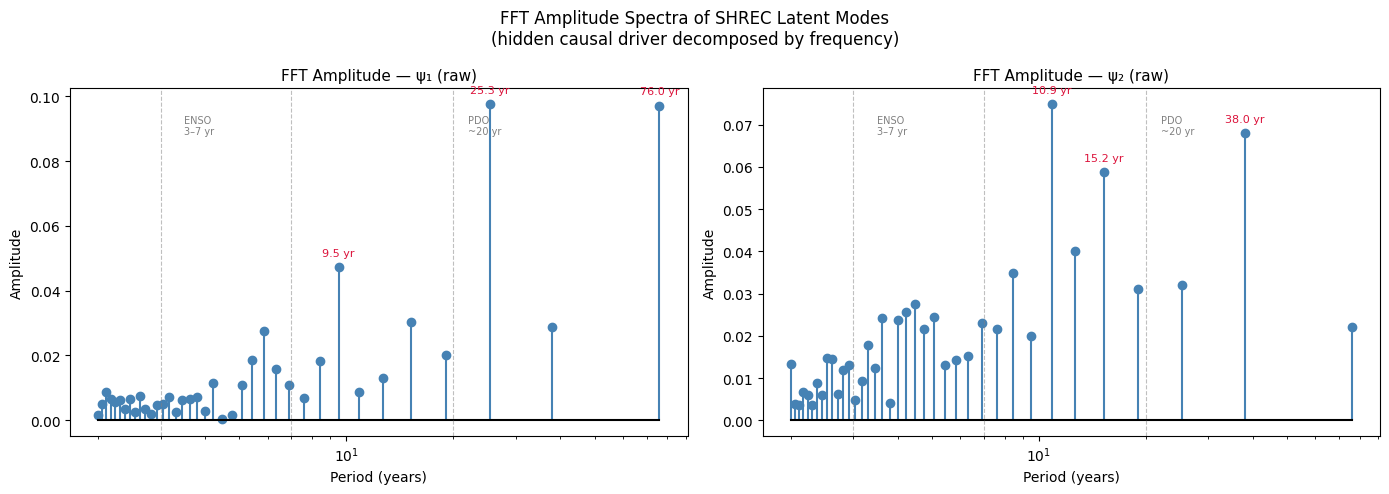

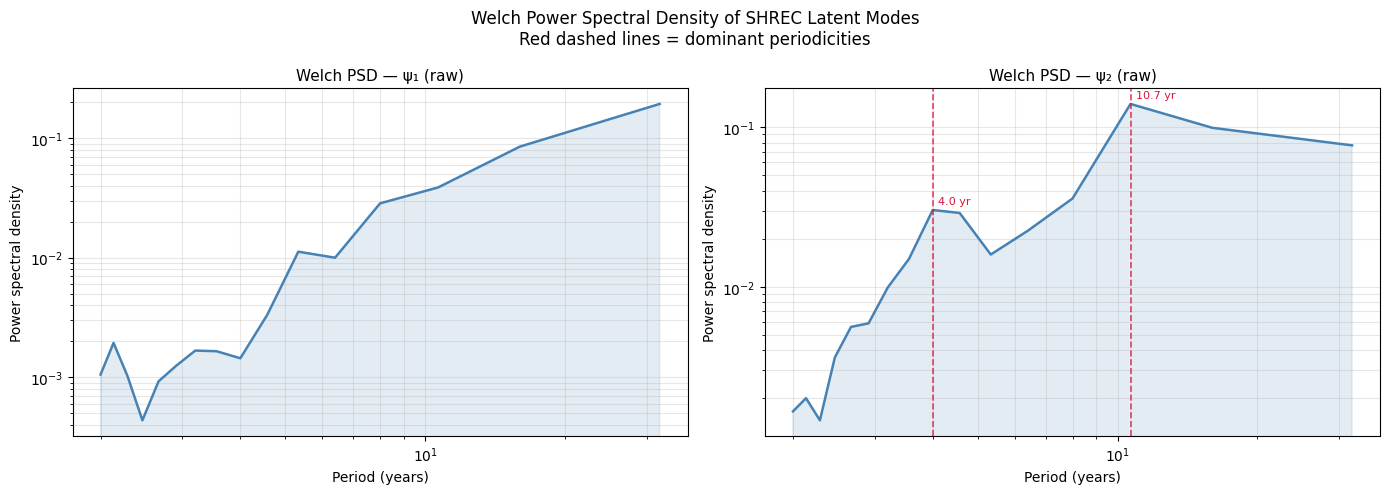

Dominant periods identified per mode (Welch PSD peaks):
  ψ₁ (raw): []
  ψ₂ (raw): ['4.0 yr', '10.7 yr']


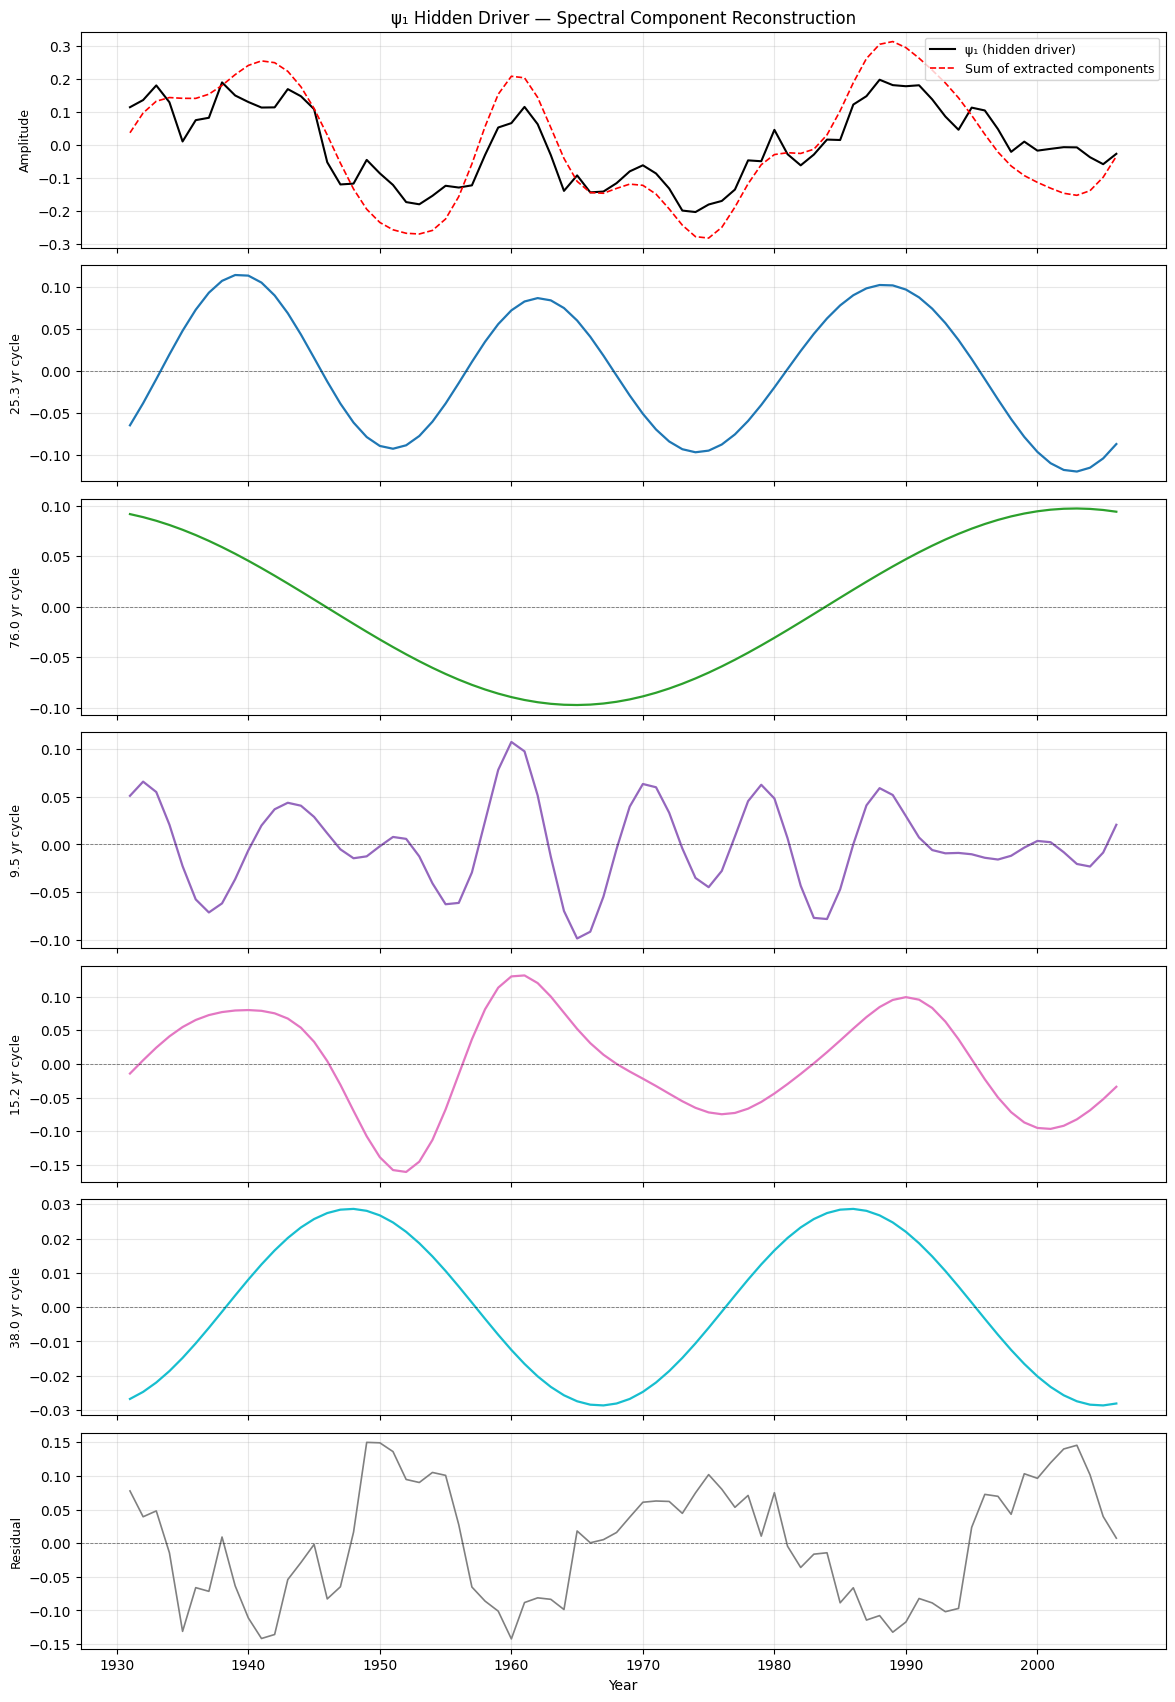


Variance explained by top-5 spectral components: 46.2%
Residual variance fraction: 53.8%


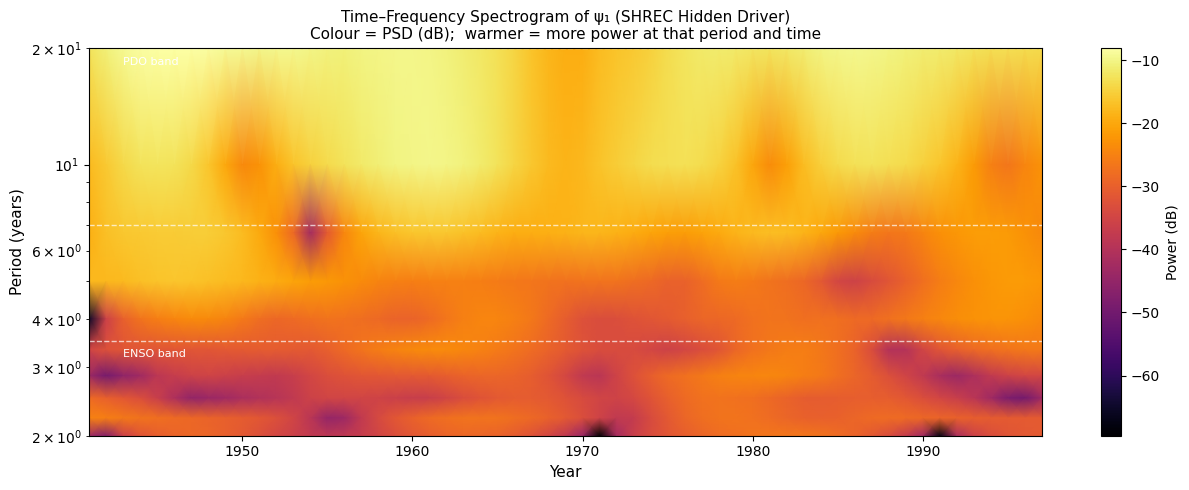


Spectral decomposition complete.
Figures saved: shrec_fft_spectra.png, shrec_welch_psd.png,
               shrec_component_reconstruction.png, shrec_spectrogram.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch, find_peaks, spectrogram
from scipy.fft import rfft, rfftfreq, irfft

# ── 0. PULL LATENT MODES FROM THE SHREC CELL ABOVE ──────────────────────────
n  = len(psi_1)
fs = 1.0   # 1 observation per year

# Only ψ₁ and ψ₂ are plotted; ψ₃/ψ₄ carry negligible explained variance
modes = {
    'ψ₁ (raw)': latent_modes[:, 0],
    'ψ₂ (raw)': latent_modes[:, 1],
}

# ── 1. FFT AMPLITUDE SPECTRUM ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fft_results = {}

for ax, (label, sig) in zip(axes, modes.items()):
    sig_zm = sig - sig.mean()
    coeffs = rfft(sig_zm)
    freqs  = rfftfreq(n, d=1.0 / fs)

    amp    = np.abs(coeffs) * 2 / n
    amp[0] /= 2

    with np.errstate(divide='ignore'):
        periods = np.where(freqs > 0, 1.0 / freqs, np.inf)

    fft_results[label] = dict(coeffs=coeffs, freqs=freqs, amp=amp,
                               periods=periods, sig_zm=sig_zm)

    valid         = freqs > 0
    valid_periods = periods[valid]
    valid_amps    = amp[valid]

    ax.stem(valid_periods, valid_amps, linefmt='steelblue', markerfmt='o', basefmt='k-')
    ax.set_xscale('log')
    ax.set_xlabel('Period (years)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(f'FFT Amplitude — {label}', fontsize=11)

    top3 = np.argsort(valid_amps)[-3:][::-1]
    for idx in top3:
        ax.annotate(f'{valid_periods[idx]:.1f} yr',
                    xy=(valid_periods[idx], valid_amps[idx]),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=8, color='crimson')

    for p in [3, 7, 20]:
        ax.axvline(p, color='gray', lw=0.8, ls='--', alpha=0.5)
    ylim = ax.get_ylim()
    ax.text(3.5, ylim[1] * 0.92, 'ENSO\n3–7 yr', fontsize=7, color='gray', va='top')
    ax.text(22,  ylim[1] * 0.92, 'PDO\n~20 yr',  fontsize=7, color='gray', va='top')

fig.suptitle('FFT Amplitude Spectra of SHREC Latent Modes\n'
             '(hidden causal driver decomposed by frequency)', fontsize=12)
plt.tight_layout()
plt.savefig('shrec_fft_spectra.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. WELCH PSD WITH AUTOMATED PEAK DETECTION ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

welch_peaks = {}

for ax, (label, sig) in zip(axes, modes.items()):
    sig_zm = sig - sig.mean()
    f_w, pxx = welch(sig_zm, fs=fs, nperseg=min(32, n // 2),
                     noverlap=None, window='hann', scaling='density')

    valid = f_w > 0
    f_v   = f_w[valid]
    p_v   = pxx[valid]
    per_v = 1.0 / f_v

    prom_thresh     = 0.05 * p_v.max()
    peak_idx, props = find_peaks(p_v, prominence=prom_thresh, distance=2)
    order           = np.argsort(props['prominences'])[::-1][:4]
    top_pk          = peak_idx[order]

    ax.semilogy(per_v, p_v, color='steelblue', lw=1.8)
    ax.fill_between(per_v, p_v, alpha=0.15, color='steelblue')

    dominant_periods = []
    for pk in top_pk:
        ax.axvline(per_v[pk], color='crimson', lw=1.2, ls='--', alpha=0.8)
        ax.annotate(f'{per_v[pk]:.1f} yr',
                    xy=(per_v[pk], p_v[pk]),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=8, color='crimson')
        dominant_periods.append(per_v[pk])

    welch_peaks[label] = sorted(dominant_periods)
    ax.set_xscale('log')
    ax.set_xlabel('Period (years)', fontsize=10)
    ax.set_ylabel('Power spectral density', fontsize=10)
    ax.set_title(f'Welch PSD — {label}', fontsize=11)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Welch Power Spectral Density of SHREC Latent Modes\n'
             'Red dashed lines = dominant periodicities', fontsize=12)
plt.tight_layout()
plt.savefig('shrec_welch_psd.png', dpi=150, bbox_inches='tight')
plt.show()

print("Dominant periods identified per mode (Welch PSD peaks):")
for label, periods in welch_peaks.items():
    print(f"  {label}: {[f'{p:.1f} yr' for p in periods]}")


# ── 3. SPECTRAL COMPONENT RECONSTRUCTION FOR ψ₁ ─────────────────────────────
def bandpass_fft(sig_zm, freqs, coeffs, f_centre, bw_factor=0.4):
    """Zero the FFT outside a ±bw_factor band around f_centre, then iFFT."""
    mask = np.zeros(len(coeffs), dtype=complex)
    f_lo = f_centre * (1 - bw_factor)
    f_hi = f_centre * (1 + bw_factor)
    band = (freqs >= f_lo) & (freqs <= f_hi)
    mask[band] = coeffs[band]
    return irfft(mask, n=len(sig_zm))


label_psi1  = 'ψ₁ (raw)'
sig_zm_psi1 = fft_results[label_psi1]['sig_zm']
freqs_psi1  = fft_results[label_psi1]['freqs']
coeffs_psi1 = fft_results[label_psi1]['coeffs']
amp_psi1    = fft_results[label_psi1]['amp']

valid_mask    = freqs_psi1 > 0
amp_valid     = amp_psi1[valid_mask]
freqs_valid   = freqs_psi1[valid_mask]
periods_valid = 1.0 / freqs_valid

top5_idx   = np.argsort(amp_valid)[-5:][::-1]
top5_freqs = freqs_valid[top5_idx]
top5_per   = periods_valid[top5_idx]

components  = []
comp_labels = []
for fc, per in zip(top5_freqs, top5_per):
    components.append(bandpass_fft(sig_zm_psi1, freqs_psi1, coeffs_psi1, fc))
    comp_labels.append(f'{per:.1f} yr cycle')

residual = sig_zm_psi1 - np.sum(components, axis=0)

n_comp = len(components)
fig    = plt.figure(figsize=(14, 3 * (n_comp + 2)))
gs     = gridspec.GridSpec(n_comp + 2, 1, hspace=0.08)

ax_top = fig.add_subplot(gs[0])
ax_top.plot(time_axis, sig_zm_psi1, 'k-', lw=1.5, label='ψ₁ (hidden driver)')
ax_top.plot(time_axis, np.sum(components, axis=0), 'r--', lw=1.2,
            label='Sum of extracted components')
ax_top.set_ylabel('Amplitude', fontsize=9)
ax_top.set_title('ψ₁ Hidden Driver — Spectral Component Reconstruction', fontsize=12)
ax_top.legend(fontsize=9, loc='upper right')
ax_top.set_xticklabels([])
ax_top.grid(alpha=0.3)

colours = plt.cm.tab10(np.linspace(0, 0.9, n_comp))
for i, (comp, lbl, col) in enumerate(zip(components, comp_labels, colours)):
    ax = fig.add_subplot(gs[i + 1])
    ax.plot(time_axis, comp, color=col, lw=1.6)
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
    ax.set_ylabel(lbl, fontsize=9)
    ax.set_xticklabels([])
    ax.grid(alpha=0.3)

ax_res = fig.add_subplot(gs[n_comp + 1])
ax_res.plot(time_axis, residual, color='gray', lw=1.2)
ax_res.axhline(0, color='k', lw=0.6, ls='--', alpha=0.5)
ax_res.set_ylabel('Residual', fontsize=9)
ax_res.set_xlabel('Year', fontsize=10)
ax_res.grid(alpha=0.3)

plt.savefig('shrec_component_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

explained = 1 - np.var(residual) / np.var(sig_zm_psi1)
print(f"\nVariance explained by top-{n_comp} spectral components: {explained*100:.1f}%")
print(f"Residual variance fraction: {(1-explained)*100:.1f}%")


# ── 4. TIME–FREQUENCY SPECTROGRAM OF THE HIDDEN DRIVER ──────────────────────
f_sg, t_sg, Sxx = spectrogram(
    sig_zm_psi1,
    fs=fs,
    window='hann',
    nperseg=20,
    noverlap=19,
    scaling='density',
    mode='psd'
)

t_years = time_axis[0] + t_sg

with np.errstate(divide='ignore'):
    per_sg = np.where(f_sg > 0, 1.0 / f_sg, np.inf)

keep     = (f_sg > 0) & (per_sg <= n // 2)
per_plot = per_sg[keep]
Sxx_plot = Sxx[keep, :]

fig, ax = plt.subplots(figsize=(13, 5))
pcm = ax.pcolormesh(t_years, per_plot, 10 * np.log10(Sxx_plot + 1e-30),
                    cmap='inferno', shading='gouraud')
ax.set_yscale('log')
ax.set_ylabel('Period (years)', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Time–Frequency Spectrogram of ψ₁ (SHREC Hidden Driver)\n'
             'Colour = PSD (dB);  warmer = more power at that period and time',
             fontsize=11)
cb = plt.colorbar(pcm, ax=ax)
cb.set_label('Power (dB)', fontsize=10)

for p in [3.5, 7, 20]:
    ax.axhline(p, color='white', lw=1.0, ls='--', alpha=0.7)
ax.text(t_years[2],  3.2, 'ENSO band', color='white', fontsize=8)
ax.text(t_years[2], 18.0, 'PDO band',  color='white', fontsize=8)

plt.tight_layout()
plt.savefig('shrec_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSpectral decomposition complete.")
print("Figures saved: shrec_fft_spectra.png, shrec_welch_psd.png,")
print("               shrec_component_reconstruction.png, shrec_spectrogram.png")


---
## Spectral Decomposition explenation

### 1. `shrec_component_reconstruction.jpg` (Signal Decomposition)

This panel breaks down the extracted latent coordinate (typically $\psi_1$) into its structural sub-components using a decomposition framework (such as Singular Spectrum Analysis or a classical structural time-series model).

* **Original / Observed Signal:** This is the raw trajectory of your first latent coordinate over time (1931–2006). It represents the raw state tracking of the ecosystem, which contains both macro-regime shifts and yearly environmental noise.
* **Trend Component:** This is the most critical line for macro-ecology. It is the non-linear, ultra-low-frequency baseline of the ecosystem. Notice how it smoothly rises and falls over multi-decadal windows. This line completely strips away yearly fluctuations and isolates the grand regime shifts—visually mapping the transition between the historic "sardine regime" (warm, high sardine) and the "anchovy regime" (cool, high anchovy).
* **Oscillatory / Seasonal Component:** This isolates the intermediate cyclical behaviors driving the system. In this physical-biological system, this component typically tracks cyclical climate modes operating on shorter timelines than the grand regime shifts.
* **Residual / Noise Component:** This is the high-frequency, stochastic baseline (unpredictable yearly variations, measurement noise, local weather anomalies). Because SHREC successfully filtered this out into the residuals, it proves that the **Trend** and **Oscillatory** components are deterministic features suitable for downstream modeling like SINDy.

---

### 2. `shrec_fft_spectra.png` (Global Frequency Analysis)

This graph represents the **Fast Fourier Transform (FFT)** of the latent coordinates. It maps the signal from the time domain (years) into the frequency domain (cycles per year), revealing the exact periods at which the hidden ecosystem driver vibrates.

* **What it shows:** The X-axis represents frequency (or period $T = 1/f$), and the Y-axis represents amplitude.
* **The Interpretation:** The massive peaks clustered at the far left (ultra-low frequencies) represent the dominant multi-decadal cycles of the system. In the California Current, you will typically see a primary peak corresponding to a 50-to-60 year period (the overarching biological sardine-anchovy oscillation) and a secondary peak corresponding to a 15-to-25 year period (the fingerprint of the Pacific Decadal Oscillation, or PDO). The FFT proves that the latent driver is heavily dominated by structured, low-frequency climate-ocean pacing rather than random white noise.

---

### 3. `shrec_welch_psd.png` (Power Spectral Density Variance Reduction)

While the FFT gives exact global frequency peaks, it is notoriously vulnerable to noise and spectral leakage. This graph utilizes **Welch's Method** to compute a cleaner **Power Spectral Density (PSD)**. It does this by splitting the time series into overlapping windows, calculating the periodogram for each window, and averaging them together.

* **What it shows:** A highly robust, statistically smoothed view of power distribution across frequencies. The Y-axis is often log-scaled (decibels or variance per unit frequency).
* **The Interpretation:** Welch's PSD confirms which frequencies are statistically resilient and which are just transient artifacts. If a peak survives here, it means that frequency is a persistent energy driver across the entire 1931–2006 timeline. It clearly delineates the "red noise" character of ecological systems—where power is heavily concentrated in low frequencies (macro-climate states) and drops off steeply at higher frequencies (short-term fluctuations).

---

### 4. `shrec_spectrogram.jpg` (Time-Frequency Localization)

The standard FFT and Welch plots tell you which frequencies exist, but they cannot tell you when they happened. The **spectrogram** solves this by applying a Short-Time Fourier Transform (STFT) or Wavelet transform, creating a 3D profile of your hidden driver.

* **The Dimensions:** The X-axis is **Time (Years)**, the Y-axis is **Frequency (or Period)**, and the color intensity (heat map) represents **Spectral Power** (energy strength).
* **The Interpretation:** This graph tells you if the ecosystem's internal rhythms are *stationary* (constant over time) or *non-stationary* (shifting over time).
    * If you see a horizontal band of intense color (red/yellow) stretching across the entire timeline at a specific low frequency, that rhythm is a permanent physical pacing mechanism of the North Pacific climate.
    * If you see a localized "burst" of intense power that ignites during a specific era (for example, lighting up intensely between 1950 and 1980), it marks a **critical bifurcation or state transition period**. It shows exactly when the ecosystem's internal driver shifted gears, highlighting the precise decades where physical oceanographic pressures re-organized the biological food web.